# Graph classification sweep performance 

Plots showing the performance for the graph classification on the Legnini data.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer

In [1]:
LRZ = "/dss/dsshome1/05/di93tig/1_projects/"
HPC = "/home/icb/francesca.drummer/1-Projects/"

In [2]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{HPC}InterScale_reproducibility')
sys.path.insert(0, str(project_root))

In [3]:
import wandb
import pandas as pd
wandb.login()

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# ste sys path correctly
#from src.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_robustness
from src.wandb import Wandb_evaluation

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: francesca-drummer. Use `wandb login --relogin` to force relogin


## Load WandB IDs

In [16]:
GNN_sweep = "qo1bqpw1"
InterScale_sweep = "o49vv5f9"
PCATrans_sweep = "g7at1od1"

## Graph Classification performance

In [17]:
SWEEP_GOAL = 'robustness'

Q: Why does PCATrans not have test_f1 scores?

In [92]:
GNN_wandb = Wandb_evaluation(GNN_sweep, SWEEP_GOAL, ['Ctrl', 'SHH'])
PCATrans_wandb = Wandb_evaluation(PCATrans_sweep, SWEEP_GOAL, ['Ctrl', 'SHH'])
InterScale_wandb = Wandb_evaluation(InterScale_sweep, SWEEP_GOAL, ['Ctrl', 'SHH'])

In [44]:
InterScale_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1/class_Ctrl,test_f1/class_SHH
0,2f3kya9h,legnini23_clas_graph_44_self-attn-transformer_,41,finished,0.5,300,None,870.316325,19346,1,None,1,1
1,rjym4nwz,legnini23_clas_graph_44_self-attn-transformer_,40,finished,0.5,300,None,840.120521,19346,1,None,1,1
2,fg8uvciu,legnini23_clas_graph_44_self-attn-transformer_,44,finished,0.5,200,None,973.558153,19346,1,None,1,1
3,ajdnzwze,legnini23_clas_graph_44_self-attn-transformer_,43,finished,0.5,200,None,922.774045,19346,1,None,1,1
4,8drdk7mn,legnini23_clas_graph_44_self-attn-transformer_,42,finished,0.5,200,None,1348.012221,19346,1,None,1,1


In [110]:
InterScale_wandb.get_mean_and_std()

,pct_mask_nodes,radius,mean_test_acc,std_test_acc,mean_test_f1_class_0,std_test_f1_class_0,mean_test_f1_class_1,std_test_f1_class_1
0,0.00,0,1.0,0.0,1.0,0.0,1.0,0.0
1,0.00,100,1.0,0.0,1.0,0.0,1.0,0.0
2,0.00,200,1.0,0.0,1.0,0.0,1.0,0.0
3,0.00,300,1.0,0.0,1.0,0.0,1.0,0.0
4,0.10,0,1.0,0.0,1.0,0.0,1.0,0.0
5,0.10,100,1.0,0.0,1.0,0.0,1.0,0.0
6,0.10,200,1.0,0.0,1.0,0.0,1.0,0.0
7,0.10,300,1.0,0.0,1.0,0.0,1.0,0.0
8,0.25,0,1.0,0.0,1.0,0.0,1.0,0.0
9,0.25,100,1.0,0.0,1.0,0.0,1.0,0.0


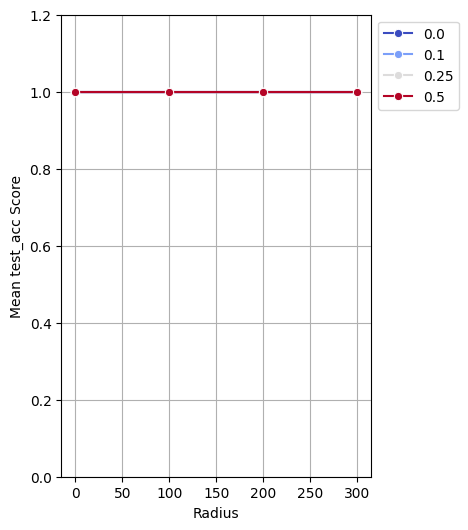

In [73]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/melton25/graph_class")

[('mean_test_acc', 'std_test_acc', 'test_acc')]


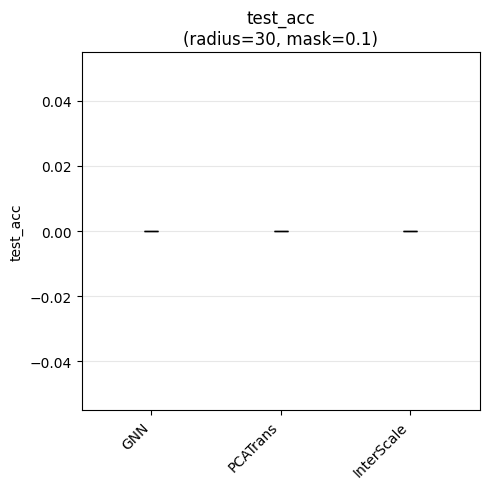

In [112]:
import numpy as np

radius = 30
pct_mask_nodes = 0.1
metric = ["test_acc"]

custom_palette = {
        "PCATrans": "#BABABE", 
        "GNN": "#88C8B2",  
        "InterScale": "#005F73",
    }

df_dict = {
    'GNN': GNN_wandb.get_mean_and_std(), 
    'PCATrans': PCATrans_wandb.get_mean_and_std(), 
    'InterScale': InterScale_wandb.get_mean_and_std()
}

# Filter dataframes and prepare data
filtered_data = {}
for model_name, df in df_dict.items():
    filtered = df[
        (df['pct_mask_nodes'] == pct_mask_nodes) & 
        (df['radius'] == radius) 
    ]
    filtered_data[model_name] = filtered

# Create metric list as tuples (mean_col, std_col, title)
metric_list = [(f'mean_{m}', f'std_{m}', m) for m in metric]
print(metric_list)

# Create barplots for each metric
fig, axes = plt.subplots(1, len(metric), figsize=(5*len(metric), 5))
if len(metric) == 1:
    axes = [axes]

for ax, (mean_col, std_col, title) in zip(axes, metric_list):
    x_pos = np.arange(len(filtered_data))
    means = [filtered_data[model][mean_col].values[0] if len(filtered_data[model]) > 0 else 0 
             for model in df_dict.keys()]
    stds = [filtered_data[model][std_col].values[0] if len(filtered_data[model]) > 0 else 0 
            for model in df_dict.keys()]
    colors = [custom_palette[model] for model in df_dict.keys()]
    
    ax.bar(x_pos, means, yerr=stds, color=colors, alpha=0.8, 
           capsize=5, error_kw={'linewidth': 2})
    ax.set_xticks(x_pos)
    ax.set_xticklabels(df_dict.keys(), rotation=45, ha='right')
    ax.set_ylabel(title)
    ax.set_title(f'{title}\n(radius={radius}, mask={pct_mask_nodes})')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()